## **Spending Habits Analysis|Credit card transaction**


📌 Project Introduction: Transaction Forecasting & Anomaly Detection
========================================

This project focuses on analyzing credit card transactions to uncover spending patterns and forecast future trends using Facebook Prophet. The goal is to help financial institutions and businesses enhance budgeting, marketing, and customer experience through predictive analytics.


**Key Objectives**
1. **Analyze Spending Behavior 🛒**

   


*   Identify top spending categories and transaction trends.

*   Detect seasonal patterns and peak spending periods.


2. **Forecast Future Transactions 📈**


*   Use time-series forecasting (Facebook Prophet) to predict future spending.

*  Incorporate external factors (holidays, economic indicators).

3. **Anomaly Detection 🚨**


*   Identify unusual spending behaviors and potential fraud.

*   Differentiate normal variations from actual anomalies.

4. **Deployment & Usability 🚀**



*   Develop a Streamlit web app for interactive forecasting.

*   Enable real-time transaction monitoring for businesses.

In [ ]:
!pip install --upgrade mlxtend -q
!pip install --upgrade category-encoders -q
!pip install scikit-learn==1.6.0 -q
!pip install prophet -q
!pip install kaleido -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 4.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

import seaborn as sns
import numpy as np
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from mlxtend.frequent_patterns import apriori, association_rules
import pickle
import os
from itertools import product
from prophet import Prophet
# Load dataset

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore',category=FutureWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
df = pd.read_csv("/content/credit_card_transactions.csv (4).zip")
df.head

<bound method NDFrame.head of          Unnamed: 0 trans_date_trans_time               cc_num  \
0                 0   2019-01-01 00:00:18     2703186189652095   
1                 1   2019-01-01 00:00:44         630423337322   
2                 2   2019-01-01 00:00:51       38859492057661   
3                 3   2019-01-01 00:01:16     3534093764340240   
4                 4   2019-01-01 00:03:06      375534208663984   
...             ...                   ...                  ...   
1296670     1296670   2020-06-21 12:12:08       30263540414123   
1296671     1296671   2020-06-21 12:12:19     6011149206456997   
1296672     1296672   2020-06-21 12:12:32     3514865930894695   
1296673     1296673   2020-06-21 12:13:36     2720012583106919   
1296674     1296674   2020-06-21 12:13:37  4292902571056973207   

                                    merchant       category     amt  \
0                 fraud_Rippin, Kub and Mann       misc_net    4.97   
1            fraud_Heller, Gutmann and Zieme    grocery_pos  107.23   
2                       fraud_Lind-Buckridge  entertainment  220.11   
3         fraud_Kutch, Hermiston and Farrell  gas_transport   45.00   
4                        fraud_Keeling-Crist       misc_pos   41.96   
...                                      ...            ...     ...   
1296670                    fraud_Reichel Inc  entertainment   15.56   
1296671             fraud_Abernathy and Sons    food_dining   51.70   
1296672                 fraud_Stiedemann Ltd    food_dining  105.93   
1296673  fraud_Reinger, Weissnat and Strosin    food_dining   74.90   
1296674  fraud_Langosh, Wintheiser and Hyatt    food_dining    4.30   

               first       last gender                         street  ...  \
0           Jennifer      Banks      F                 561 Perry Cove  ...   
1          Stephanie       Gill      F   43039 Riley Greens Suite 393  ...   
2             Edward    Sanchez      M       594 White Dale Suite 530  ...   
3             Jeremy      White      M    9443 Cynthia Court Apt. 038  ...   
4              Tyler     Garcia      M               408 Bradley Rest  ...   
...              ...        ...    ...                            ...  ...   
1296670         Erik  Patterson      M       162 Jessica Row Apt. 072  ...   
1296671      Jeffrey      White      M  8617 Holmes Terrace Suite 651  ...   
1296672  Christopher  Castaneda      M     1632 Cohen Drive Suite 639  ...   
1296673       Joseph     Murray      M           42933 Ryan Underpass  ...   
1296674      Jeffrey      Smith      M           135 Joseph Mountains  ...   

             long city_pop                                job         dob  \
0        -81.1781     3495          Psychologist, counselling  1988-03-09   
1       -118.2105      149  Special educational needs teacher  1978-06-21   
2       -112.2620     4154        Nature conservation officer  1962-01-19   
3       -112.1138     1939                    Patent attorney  1967-01-12   
4        -79.4629       99     Dance movement psychotherapist  1986-03-28   
...           ...      ...                                ...         ...   
1296670 -112.4777      258                       Geoscientist  1961-11-24   
1296671  -77.5101      100   Production assistant, television  1979-12-11   
1296672 -105.8189      899                    Naval architect  1967-08-30   
1296673 -102.5411     1126              Volunteer coordinator  1980-08-18   
1296674 -113.8748      218           Therapist, horticultural  1995-08-16   

                                trans_num   unix_time  merch_lat  merch_long  \
0        0b242abb623afc578575680df30655b9  1325376018  36.011293  -82.048315   
1        1f76529f8574734946361c461b024d99  1325376044  49.159047 -118.186462   
2        a1a22d70485983eac12b5b88dad1cf95  1325376051  43.150704 -112.154481   
3        6b849c168bdad6f867558c3793159a81  1325376076  47.034331 -112.561071   
4        a41d7549acf90789359a9aa5346dcb46  1325376186  38.6749

In [ ]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,NaN
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,22630.0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,88351.0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,69367.0


In [ ]:
df.shape

(1296675, 24)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [ ]:
df.drop(['Unnamed: 0','merch_zipcode'],axis=1,inplace = True)

In [ ]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [ ]:
df['trans_num'] = df['trans_num'].apply(lambda x: abs(hash(x)))
# why df['trans_num'].astype('int') give me the error


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat                    12966

In [ ]:
#Describe numerical feature
stats = df.describe()
stats

,trans_date_trans_time,cc_num,amt,zip,lat,long,city_pop,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,2019-10-03 12:47:28.070214144,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,4.616041e+18,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
min,2019-01-01 00:00:18,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,5.581987e+12,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,2019-06-03 19:12:22.500000,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,2.315045e+18,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,2019-10-03 07:35:47,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,4.622016e+18,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,2020-01-28 15:02:55.500000,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,6.918571e+18,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,2020-06-21 12:13:37,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,9.223362e+18,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00
std,NaN,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,2.660406e+18,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02


In [ ]:
#convert dob to Age

df['dob'] = pd.to_datetime(df['dob'])
df['customer_age'] = df['dob'].apply(lambda x: datetime.now().year - x.year)

why? Age - based speding insights(e.g., youngers vs older customer).


Total Spending Per Customer

In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'customer_age'],
      dtype='object')

In [ ]:
df['total_spent'] = df.groupby('cc_num')['amt'].transform('sum').sort_values(ascending= True)

In [ ]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,customer_age,total_spent
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,3495,"Psychologist, counselling",1988-03-09,2779943914328846756,1325376018,36.011293,-82.048315,0,37,177233.44
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,149,Special educational needs teacher,1978-06-21,5844318610388959715,1325376044,49.159047,-118.186462,0,47,163466.44
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,4154,Nature conservation officer,1962-01-19,6118258792627875550,1325376051,43.150704,-112.154481,0,63,33132.63
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,1939,Patent attorney,1967-01-12,4744746372015409504,1325376076,47.034331,-112.561071,0,58,35878.90
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,99,Dance movement psychotherapist,1986-03-28,8061278409195122666,1325376186,38.674999,-78.632459,0,39,191974.21


📌 Why?

Can be used for customer segmentation (e.g., VIP customers).

Helps in budgeting recommendations.

In [ ]:
# Transaction frequency per customer
df['transaction_counts']  = df.groupby('cc_num')['amt'].transform('count')

In [ ]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,customer_age,total_spent,transaction_counts
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,"Psychologist, counselling",1988-03-09,2779943914328846756,1325376018,36.011293,-82.048315,0,37,177233.44,2028
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,Special educational needs teacher,1978-06-21,5844318610388959715,1325376044,49.159047,-118.186462,0,47,163466.44,3030
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,Nature conservation officer,1962-01-19,6118258792627875550,1325376051,43.150704,-112.154481,0,63,33132.63,503
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,Patent attorney,1967-01-12,4744746372015409504,1325376076,47.034331,-112.561071,0,58,35878.90,493
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,Dance movement psychotherapist,1986-03-28,8061278409195122666,1325376186,38.674999,-78.632459,0,39,191974.21,2017


📌 Why?

Can help detect fraudulent activity (unusual spending spikes). Useful for personalized financial recommendations.

# Exploratory Data Analysis

Basic EDA Questions (Beginner-Level)

1.What are the top spending categories by transaction volume and amount?

2.How does spending vary over time (daily, weekly, monthly trends)?

3.What are the peak spending hours in a day?

4.What is the most common payment method used?

5.Which merchants have the highest transactions?

🔹 1. Top Spending Categories by Transaction Volume & Amount

We’ll calculate both:

Transaction Volume (Total number of transactions per category)

Total Amount Spent (Sum of all transaction amounts per category)

In [ ]:
top_spending = df.groupby('category')['amt'].sum()

In [ ]:
top_spending

,amt
category,
entertainment,6036678.56
food_dining,4672459.44
gas_transport,8351732.29
grocery_net,2439412.68
grocery_pos,14460822.38
health_fitness,4653108.02
home,7173928.11
kids_pets,6503680.16
misc_net,5117709.26


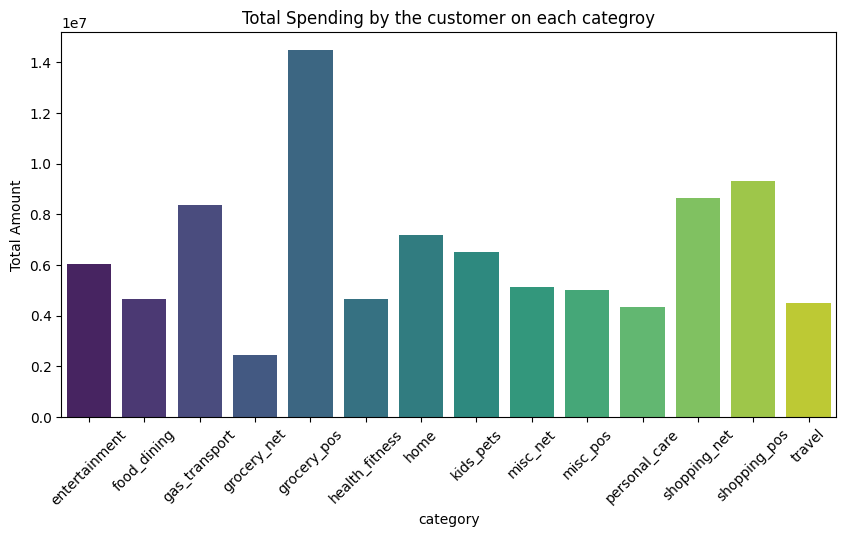

In [ ]:
plt.figure(figsize = (10,5))
sns.barplot(x = top_spending.index, y = top_spending.values,palette = 'viridis')
plt.title('Total Spending by the customer on each categroy')
plt.xlabel('category')
plt.ylabel('Total Amount')
plt.xticks(rotation = 45)
plt.savefig('top_spending.png')
plt.show()

In [ ]:
top_nos_trans = df.groupby('category')['amt'].count().sort_values(ascending=False)

In [ ]:
top_nos_trans

,amt
category,
gas_transport,131659
grocery_pos,123638
home,123115
shopping_pos,116672
kids_pets,113035
shopping_net,97543
entertainment,94014
food_dining,91461
personal_care,90758


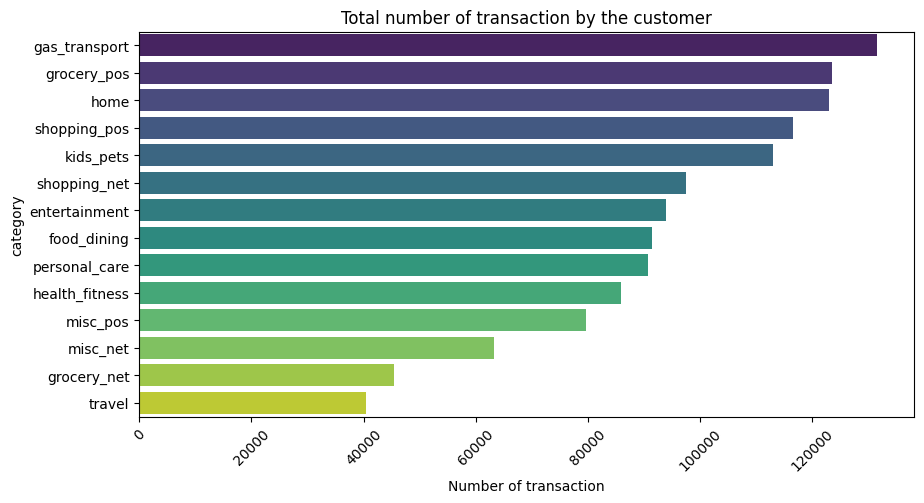

In [ ]:
plt.figure(figsize = (10,5))
sns.barplot(y = top_nos_trans.index, x = top_nos_trans.values,palette = 'viridis')
plt.title('Total number of transaction by the customer')
plt.xlabel('Number of transaction')
plt.ylabel('category')
plt.xticks(rotation = 45)
plt.savefig('top_spending.png')
plt.show()

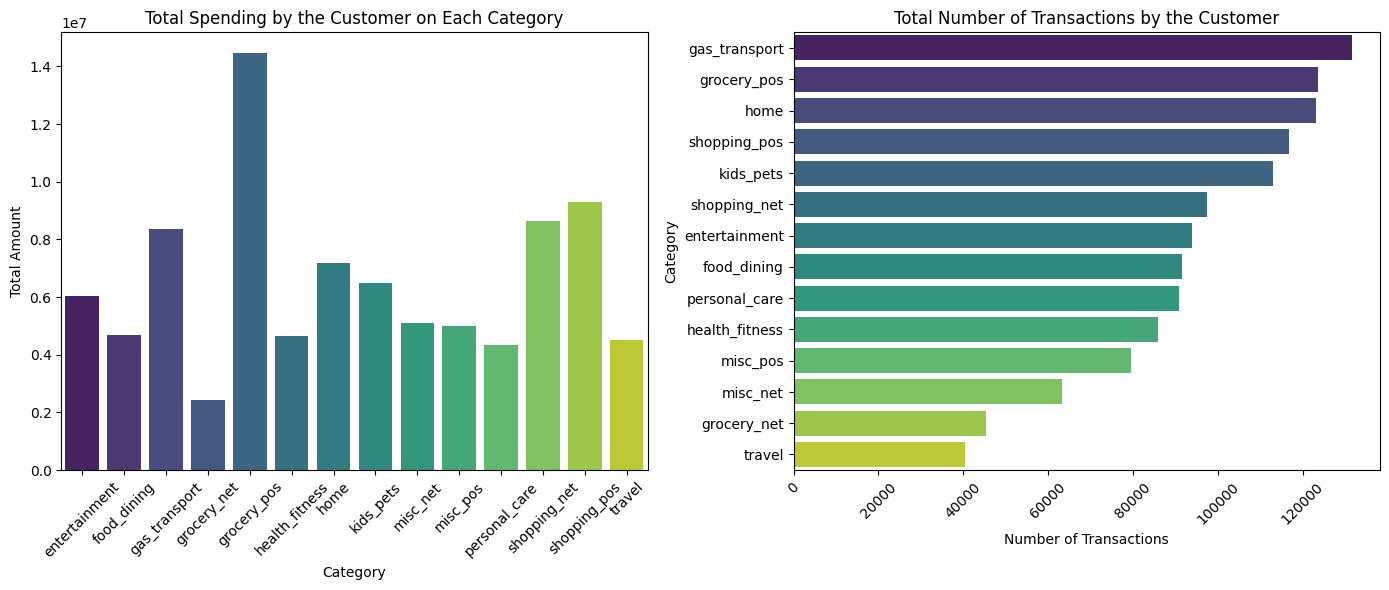

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create one figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- First subplot ---
sns.barplot(ax=axes[0], x=top_spending.index, y=top_spending.values, palette='viridis')
axes[0].set_title('Total Spending by the Customer on Each Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Amount')
axes[0].tick_params(axis='x', rotation=45)

# --- Second subplot ---
sns.barplot(ax=axes[1], x=top_nos_trans.values, y=top_nos_trans.index, palette='viridis')
axes[1].set_title('Total Number of Transactions by the Customer')
axes[1].set_xlabel('Number of Transactions')
axes[1].set_ylabel('Category')
axes[1].tick_params(axis='x', rotation=45)

# Adjust spacing
plt.tight_layout()

# Save entire figure (both plots)
plt.savefig('top_customer_analysis.png', dpi=300, bbox_inches='tight')

plt.show()


#📌 Insights: Top Spending Categories by Transaction Volume & Amount


1. Highest Transaction Volume



*   **Gas & Transport** has the highest number of transaction (**131,659**),indicating frequent spending, possibly on fuel or transportation services.

2. Highest Total Spending


*   **Grocery(POS)** leads in total spending(**~$14.46M**),making it a major expense category.

3. Shopping Trends


*   **Shopping(POS)** has more transactions (**116,672**) than **Shopping(Net)(97,543)**,but a lower total spend.


*   This suggests that online purchases might have higer average values.

4.Home-related Expenses


*   **Home spending** is significant(**$7.17M**) but has fewer transactions compared to other categories.

*   This indicates lower-value but highe frequent purchases.



📌 Insights: Significent category

1. kids_pets


*   The transaction is frequent but the spending is low means this expances is of daily uses.Meas customers not stock stacking it but purchasing frequently

2. Entertainment


*   Highe frequency but low spending means customer is usaly spending on entertainment on frequent basis may be it is on weekly basis.

3. Food dining
*   May be it alos on frequent basis may be on weekly basis.

#🔹 2. How Spending Varies Over Time (Daily, Weekly, Monthly Trends)

---



Let's analyze the spending pattern using time-based aggregations.


In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'customer_age', 'total_spent',
       'transaction_counts'],
      dtype='object')

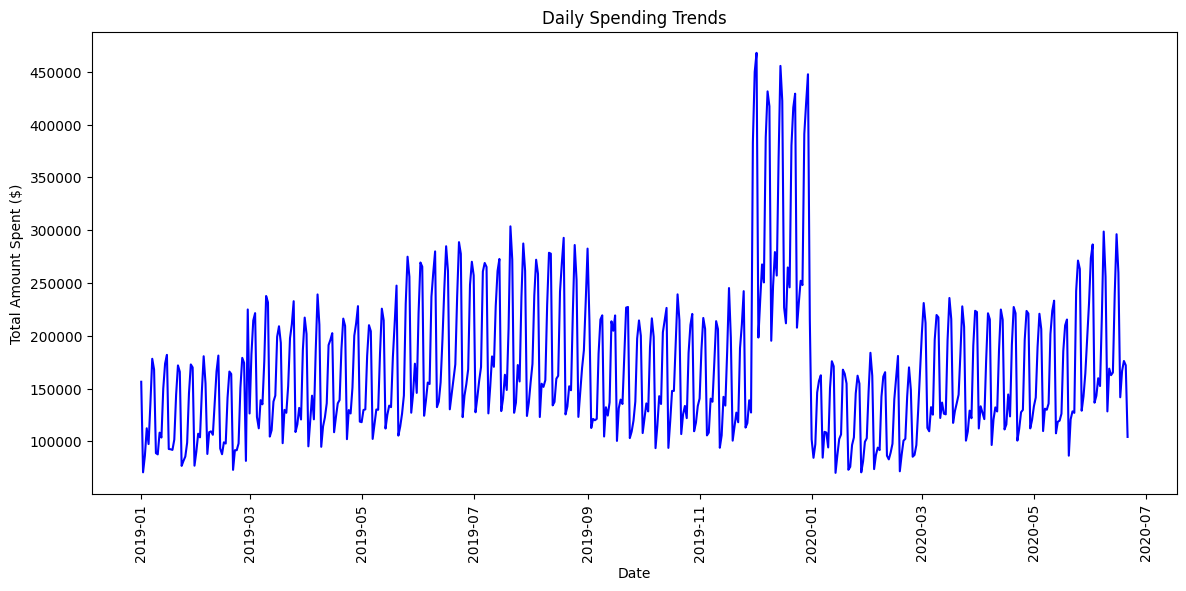

In [ ]:
df['transaction_date'] = df['trans_date_trans_time'].dt.date
daily_spending = df.groupby('transaction_date')['amt'].sum()
#Plot daily spending trend

plt.figure(figsize = (14,6))
sns.lineplot(x=daily_spending.index,y= daily_spending.values,color = 'blue')
plt.title('Daily Spending Trends')
plt.xlabel('Date')
plt.ylabel('Total Amount Spent ($)')
plt.xticks(rotation = 90)
# Save the plot with the title as the filename
plt.savefig('Daily Spending Trends.png')
plt.show()

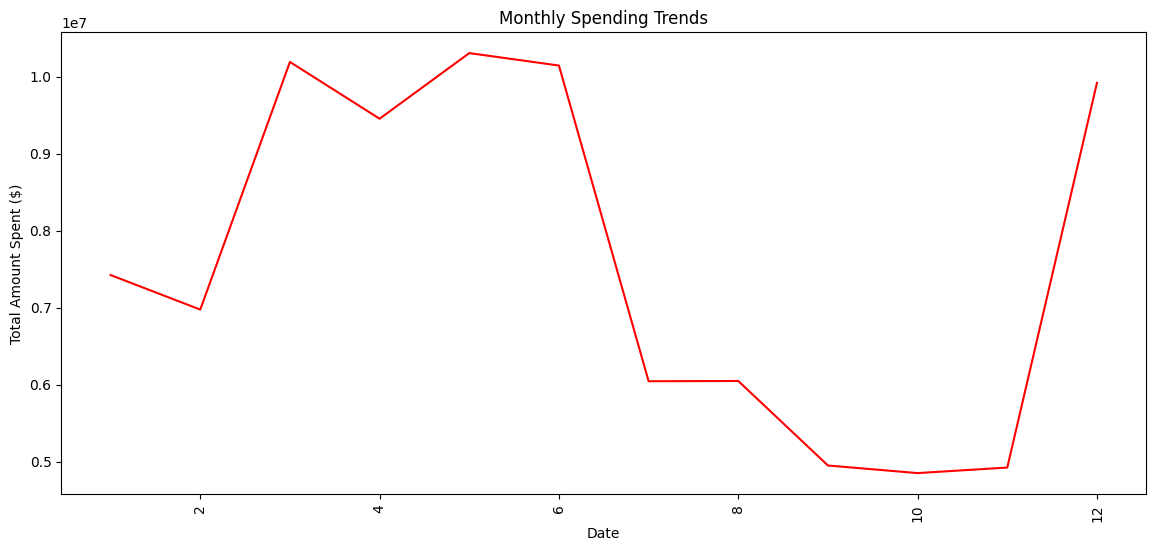

In [ ]:
df['transaction_month'] = df['trans_date_trans_time'].dt.month
month_spending = df.groupby('transaction_month')['amt'].sum()
#Plot monthly spending trend

plt.figure(figsize = (14,6))
sns.lineplot(x=month_spending.index,y= month_spending.values,color = 'red')
plt.title('Monthly Spending Trends')
plt.xlabel('Date')
plt.ylabel('Total Amount Spent ($)')
plt.xticks(rotation = 90)
# Save the plot with the title as the filename
plt.savefig('Monthly Spending Trends.png')
plt.show()

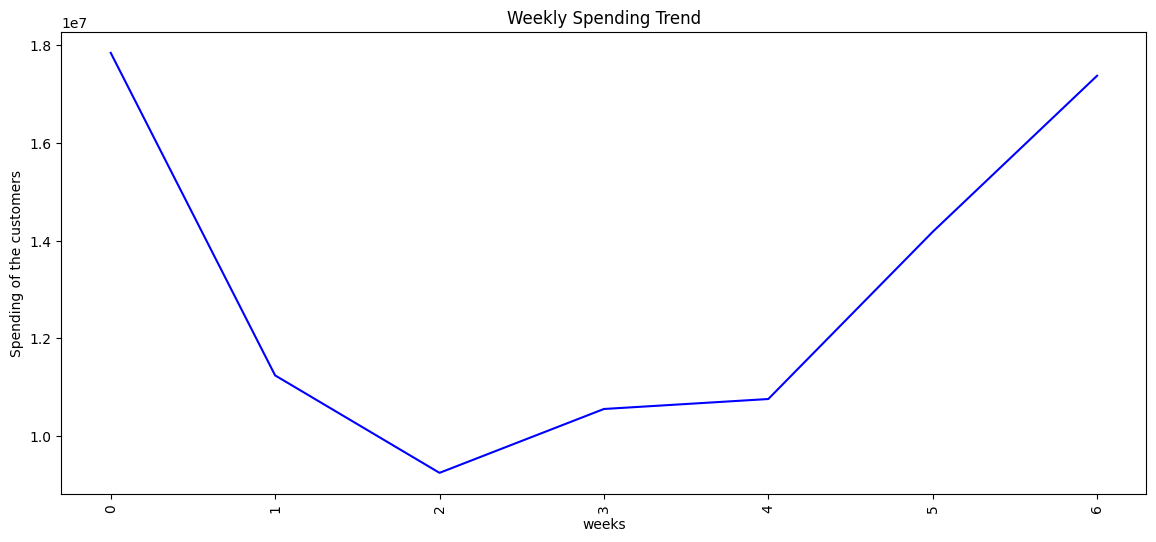

In [ ]:
df['weekly_transaction'] = df['trans_date_trans_time'].dt.dayofweek
weekly_transaction = df.groupby('weekly_transaction')['amt'].sum()

#weekly spending vizualization
plt.figure(figsize = (14,6))
sns.lineplot(x = weekly_transaction.index,y = weekly_transaction.values,color = 'b')
plt.title('Weekly Spending Trend')
plt.xlabel('weeks')
plt.ylabel('Spending of the customers')
plt.xticks(rotation = 90)
plt.savefig('Monthly_spending.png')
plt.show()

In [ ]:
df.shape

(1296675, 28)

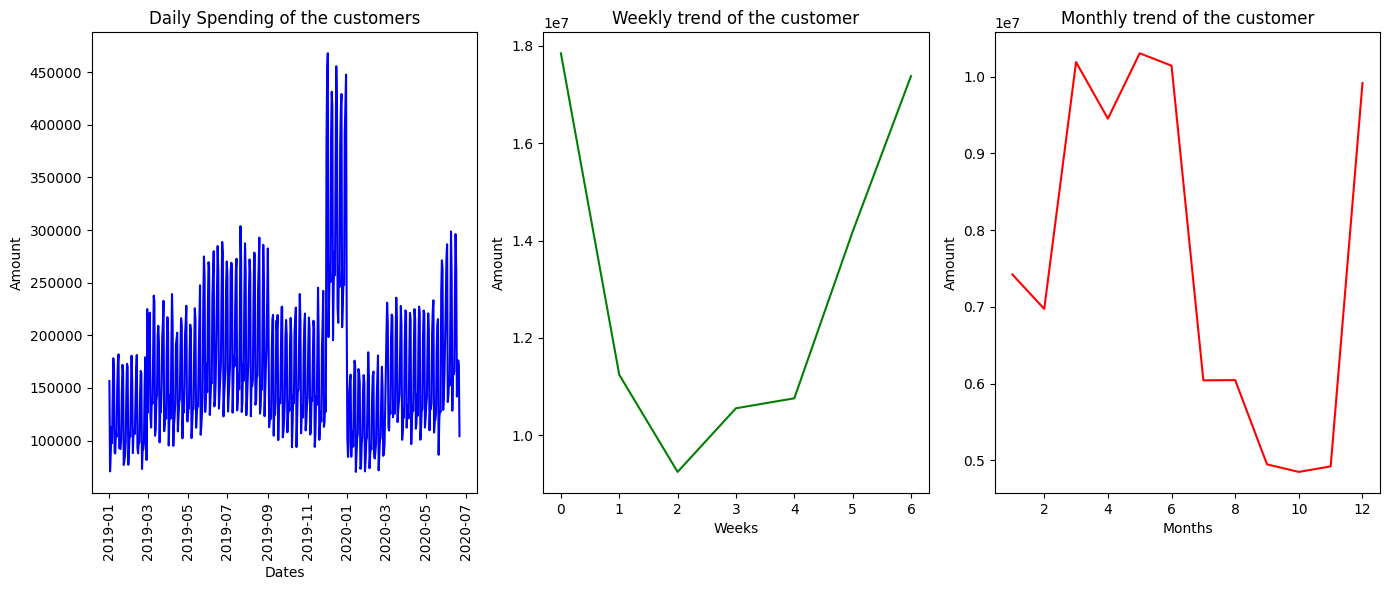

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (14,6))
sns.lineplot(ax = axes[0],x = daily_spending.index,y = daily_spending.values,color= 'blue')
axes[0].set_title('Daily Spending of the customers')
axes[0].set_xlabel('Dates')
axes[0].set_ylabel('Amount')
axes[0].tick_params(axis = 'x',rotation = 90)

sns.lineplot(ax = axes[1],x = weekly_transaction.index,y = weekly_transaction.values,color = 'green')
axes[1].set_title('Weekly trend of the customer')
axes[1].set_xlabel('Weeks')
axes[1].set_ylabel('Amount')
axes[1].tick_params(axis = 'x')


sns.lineplot(ax = axes[2],x = month_spending.index,y = month_spending.values,color = 'red')
axes[2].set_title('Monthly trend of the customer')
axes[2].set_xlabel('Months')
axes[2].set_ylabel('Amount')
axes[2].tick_params(axis = 'x')

plt.tight_layout()
plt.savefig('customer_spending.png', dpi=300, bbox_inches='tight')
plt.show()

# 📌 Insights 📊 Spending Trends Analysis

1. Daily Trends Observations



*   Spending follows a clear cyclical pattern, indicating periodic peaks and dips.

*   There is a noticeable spike around late 2019 to early 2020, possibly due to seasonal events like holidays or major purchases.


*   Post-peak, spending decreases but retains some periodic fluctuations.

2. Weekly Trends Observations

*   The trend of the weekly oscillatinos suggest that 'Customers spending get increase on weekend and that spending is pland.



*   The overall trend shows growth in spending over time, with fluctuations becoming more pronounced.
3. What Are the Peak Spending Hours in a Day?



*   A significant spike at the start of 2020 suggests a holiday or year-end effect.

*   The overall trend shows growth in spending over time, with fluctuations becoming more pronounced.

🔹 3. What Are the Peak Spending Hours in a Day?

Extract the transaction hour and visualize the trend.

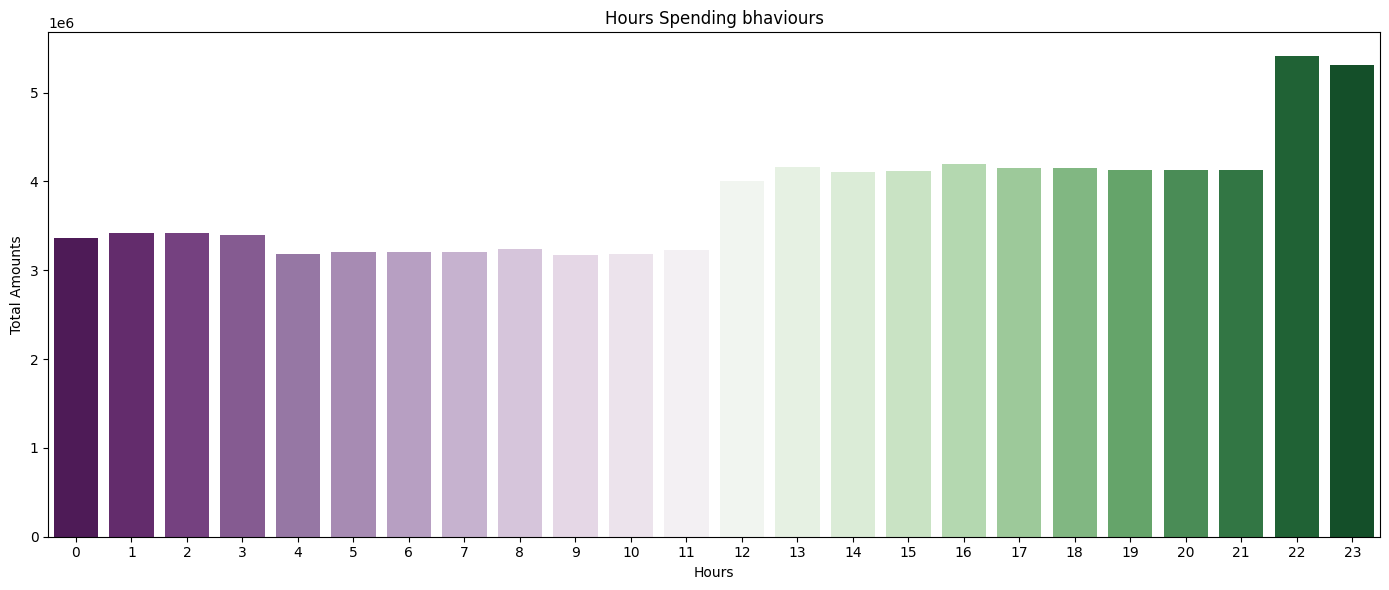

In [ ]:
df['transaction_hours'] = df['trans_date_trans_time'].dt.hour
trans_hours = df.groupby('transaction_hours')['amt'].sum()

plt.figure(figsize = (14,6))
sns.barplot(x = trans_hours.index,y= trans_hours.values,palette = 'PRGn')
plt.title('Hours Spending bhaviours')
plt.xlabel('Hours')
plt.ylabel('Total Amounts')
plt.xticks(range(0,24))
plt.savefig('Peak_spending_hours.png')
plt.tight_layout()
plt.show()

📌 Insights: 🔥 Peak Spending Summary
*   Peak spending occurs between 10PM -11Pm,likely due to online showpping or bill payments.
*  SPending Gradually increase from 12PM onwards, indicating more retail and entertaintment transactions.
*   Lowest spending happens between 4AM -8Pm , aliging with sleeping hours.
*   Evening hous drive the most transactions,making it the prime spending period.

In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'customer_age', 'total_spent',
       'transaction_counts', 'transaction_date', 'transaction_month',
       'weekly_transaction', 'transaction_hours'],
      dtype='object')

In [ ]:
df['merchant'].value_counts()

,count
merchant,
fraud_Kilback LLC,4403
fraud_Cormier LLC,3649
fraud_Schumm PLC,3634
fraud_Kuhn LLC,3510
fraud_Boyer PLC,3493
...,...
"fraud_Douglas, DuBuque and McKenzie",775
fraud_Treutel-King,775
"fraud_Medhurst, Labadie and Gottlieb",759


In [ ]:
df['merchant'] = df['merchant'].str.replace('fraud_',"",regex = False)
merchant_transactions = df['merchant'].value_counts().head(10)
merchant_transactions

,count
merchant,
Kilback LLC,4403
Cormier LLC,3649
Schumm PLC,3634
Kuhn LLC,3510
Boyer PLC,3493
Dickinson Ltd,3434
Cummerata-Jones,2736
Kutch LLC,2734
"Olson, Becker and Koch",2723


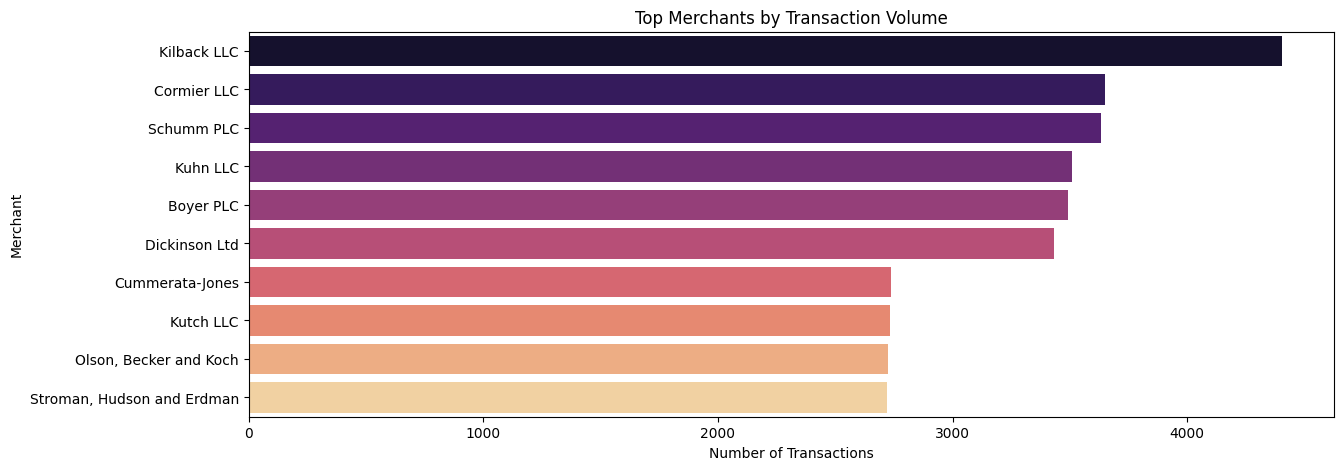

In [ ]:
plt.figure(figsize= (14,5))
sns.barplot(y= merchant_transactions.index,x = merchant_transactions.values,palette='magma' )
plt.title('Top Merchants by Transaction Volume')
plt.xlabel('Number of Transactions')
plt.ylabel('Merchant')
plt.savefig('top_merchants.png',dpi = 300,bbox_inches = 'tight')
plt.show()

#📌 Insights: 🏪 Top Merchants by Transaction Volume


*   Kilback LLC has the highest number of transactions(4,403), making it the most frequent used merhant.
*  Cormier LLC,Schumm PLC, and Kuhn LLC follow closely,each with over 3,500 transactions.


*   The top 10 merchants all have over 2,700 transaction, indecating high customer engagement.

*   The distribution suggests a mix of retail, services,and essential spending across multiple vendors.





#4.2 Intermediate EDA Questions



*   Are there seasonal trends in spending across different categories?


*   How do different customer segments (high spenders vs. low spenders) behave?


*   What is the distribution of transaction amounts (e.g., histogram, boxplot analysis)?

*   Are there any correlations between spending behavior and location?



*   How does spending behavior change before and after payday?

♦️ Part 1. Customer Segments: High Spenders vs. Low Spenders




In [ ]:
df['spending_segment'] = pd.qcut(df['total_spent'], q=[0, 0.33, 0.66, 1], labels=['Low Spender', 'Medium Spender', 'High Spender'])

In [ ]:
df['spending_segment']

,spending_segment
0,High Spender
1,High Spender
2,Low Spender
3,Low Spender
4,High Spender
...,...
1296670,Low Spender
1296671,Low Spender
1296672,Medium Spender
1296673,High Spender


In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'customer_age', 'total_spent',
       'transaction_counts', 'transaction_date', 'transaction_month',
       'weekly_transaction', 'transaction_hours', 'spending_segment'],
      dtype='object')

In [ ]:
# Step 2: Compare Spending Behavior
# Analyzing spending differences across segments:
#average transaction amount, transaction frequency,
#and top categories
Spending_Behavior = df.groupby('spending_segment').agg({'transaction_counts':['mean','count','max'],
                                                        'amt':['sum','mean','max','min'],
                                                        'category':lambda x:x.mode()[0]})
Spending_Behavior

transaction_counts                        amt             \
                               mean   count   max          sum       mean   
spending_segment                                                            
Low Spender             1033.496108  427923  1571  29085565.16  67.969156   
Medium Spender          1859.805970  429011  2588  28109597.92  65.521858   
High Spender            2542.773339  439741  3123  34027265.82  77.380244   

                                      category  
                       max  min       <lambda>  
spending_segment                                
Low Spender       27390.12  1.0  gas_transport  
Medium Spender    15034.18  1.0  gas_transport  
High Spender      28948.90  1.0           home

🔹 Part 2: Analyzing & Comparing Behavior Across Segments.

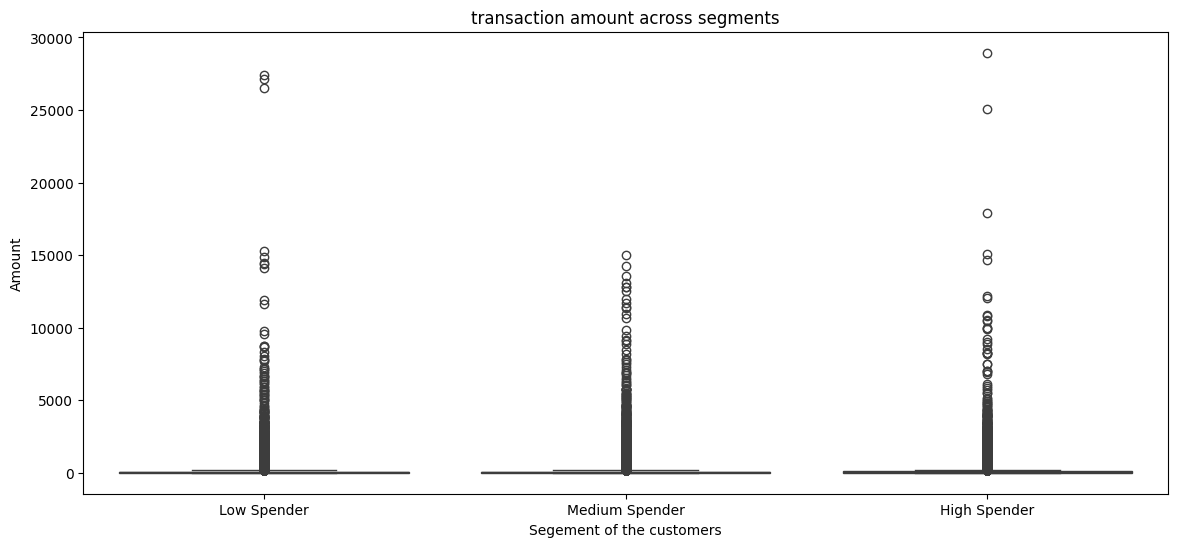

In [ ]:
# Step 3: Visualize Spending Behavior
# Boxplot to compare transaction amounts across segments
plt.figure(figsize = (14,6))
sns.boxplot(x = 'spending_segment', y = 'amt',data = df,hue= 'spending_segment')
plt.title('transaction amount across segments')
plt.xlabel('Segement of the customers')
plt.ylabel('Amount')
plt.savefig("Transaction Amount Distribution by Spending Segment.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'customer_age', 'total_spent',
       'transaction_counts', 'transaction_date', 'transaction_month',
       'weekly_transaction', 'transaction_hours', 'spending_segment'],
      dtype='object')

In [ ]:
# Step 4: Top Merchants per Segment
# Identifying the most frequent merchants per spending segment
top_merchants  = df.groupby('spending_segment')['merchant'].value_counts().groupby(level = 0).head(5)
top_merchants

spending_segment  merchant     
Low Spender       Kilback LLC      1469
                  Kuhn LLC         1180
                  Cormier LLC      1156
                  Schumm PLC       1135
                  Dickinson Ltd    1133
Medium Spender    Kilback LLC      1439
                  Schumm PLC       1185
                  Cormier LLC      1163
                  Kuhn LLC         1112
                  Boyer PLC        1110
High Spender      Kilback LLC      1495
                  Cormier LLC      1330
                  Schumm PLC       1314
                  Boyer PLC        1268
                  Kuhn LLC         1218
Name: count, dtype: int64

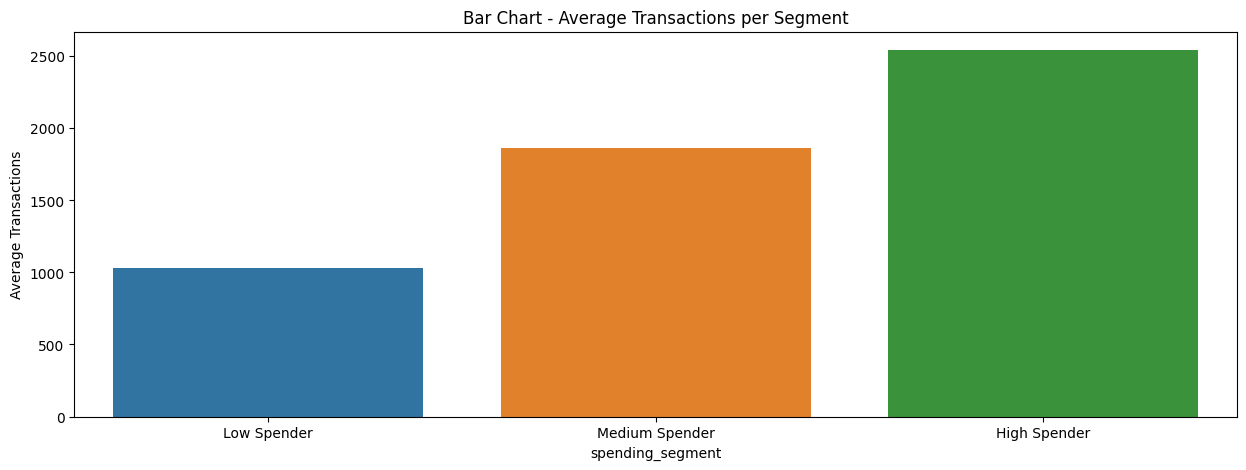

In [ ]:
#Step 5: Compare Transaction Frequency Across Segments
# 📊 Bar Chart - Average Transactions per Segment
# Calculate average transactions per segment
avg_tran_segment = df.groupby('spending_segment')['transaction_counts'].mean()
plt.figure(figsize = (15,5))
sns.barplot(x = avg_tran_segment.index,y = avg_tran_segment.values,palette='tab10')
plt.title('Bar Chart - Average Transactions per Segment')
plt.ylabel('Average Transactions')
plt.savefig("Average Transaction Count per Spending Segment.png", dpi=300, bbox_inches='tight')
plt.show()

📌 Insights:📊 Seasonal Spending Trends


*   **Spending peaks during holidays and year-end**, especially in Shopping and Home categories.

*   **Gas & Transport remains stable but rises during travel-heavy seasons.**

*   **High Spenders drive seasonal spikes, particularly in Home-related purchases.**



*   **Grocery & Shopping show increased activity during holidays and back-to-school periods.**



🔹 Part 3: What is the distribution of transaction amounts?

To analyze the distribution of transaction amounts, we can use histograms, KDE plots, and boxplots.

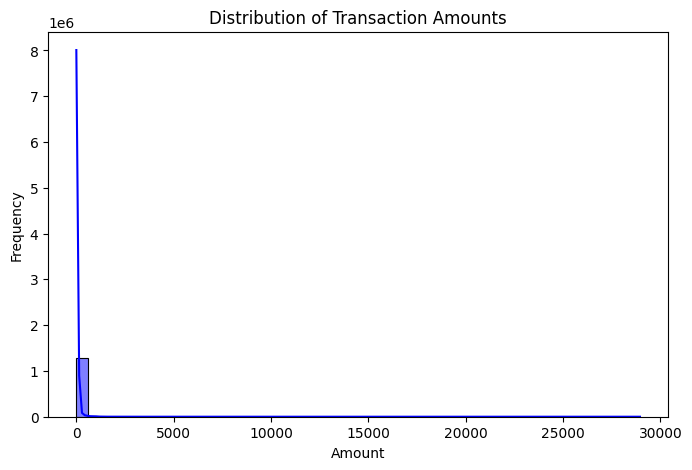

In [ ]:
# 2️⃣ Boxplot to Detect Outliers
plt.figure(figsize = (8,5))
sns.histplot(df['amt'],bins = 50,kde = True,color = 'blue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.savefig('Distribution of Transaction Amount.png',dpi = 300,bbox_inches = 'tight')
plt.show()

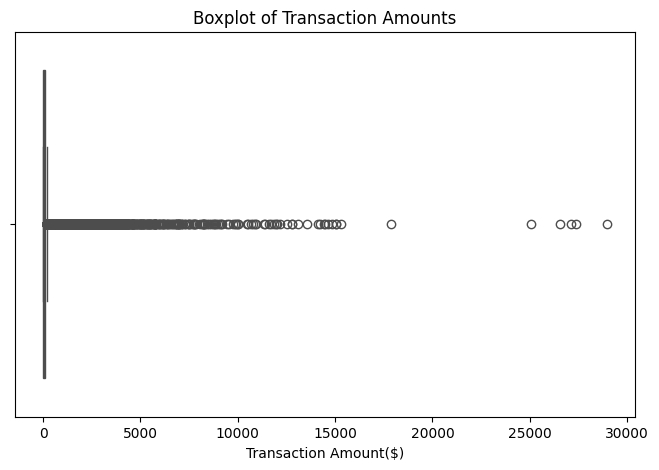

In [ ]:
plt.figure(figsize = (8,5))
sns.boxplot(x = df['amt'],color = 'red')
plt.title('Boxplot of Transaction Amounts')
plt.xlabel('Transaction Amount($)')
plt.savefig('Boxplot of Transaction Amount.png',dpi = 300,bbox_inches = 'tight')
plt.show()

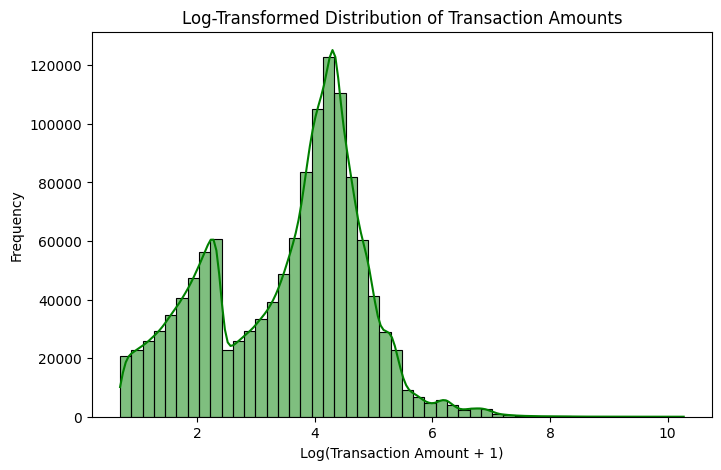

In [ ]:
# 3️⃣ Log Transformation for Better Visualization
# If the data is skewed, applying log transformation helps in better visualization

plt.figure(figsize=(8, 5))

# Histogram with log-transformed transaction amounts
sns.histplot(np.log1p(df["amt"]), bins=50, kde=True, color="green")

plt.title("Log-Transformed Distribution of Transaction Amounts")  # Title of the plot
plt.xlabel("Log(Transaction Amount + 1)")  # X-axis label
plt.ylabel("Frequency")  # Y-axis label

# Save the figure
plt.savefig("Log-Transformed Distribution of Transaction Amounts.png", dpi=300, bbox_inches='tight')
plt.show()

📌 Insights: 📊 Transaction Amount Distribution Insights



*   **Highly Skewed Data:**
The majority of transaction are low-value outliers exits.
*   **Presence of Outliers:** The boxplot reveals **extreme values above $10,000,indicating occasional high-spending transaction.


*   **Log Transformation Effect:** by the majority of the transaction is small to medium transaction.

#♦️ Part 4: Correlation Between Spending Behavior and Location (City & State)




In [ ]:
# 3️⃣ Log Transformation for Better Visualization
# If the data is skewed, applying log
#transformation helps in better visualization


♦️ Part 4: Correlation Between Spending Behavior and Location (City & State)

In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'customer_age', 'total_spent',
       'transaction_counts', 'transaction_date', 'transaction_month',
       'weekly_transaction', 'transaction_hours', 'spending_segment'],
      dtype='object')

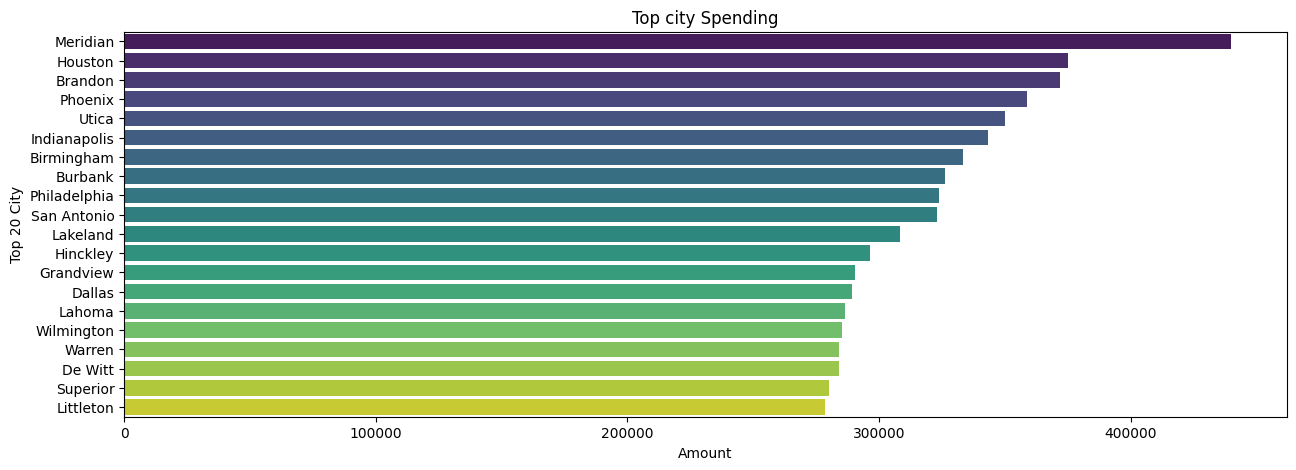

In [ ]:
city_spending = df.groupby('city')['amt'].sum().sort_values(ascending= False).head(20)
plt.figure(figsize = (15,5))
sns.barplot(y = city_spending.index, x = city_spending.values,palette="viridis")
plt.title('Top city Spending')
plt.xlabel('Amount')
plt.ylabel('Top 20 City')
plt.savefig("Top Cities by Total Spending.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 2️⃣ Heatmap of Spending Across States
state_spending = df.groupby("state")["amt"].sum().reset_index()
fig2 = px.choropleth(state_spending, locations='state', locationmode='USA-states', color='amt',
                      title='Total Spending by State', color_continuous_scale='Viridis')
fig2.update_geos(scope="usa")

# --- Save as an Image ---
try:
    fig2.write_image("Total_Spending_by_state.png", scale=2)
    print("Image saved as Total_Spending_by_state.png")
except ValueError as e:
    print(f"Could not save image: {e}")
    print("Please ensure the 'kaleido' package is correctly installed and accessible.")


# --- Save as an Interactive HTML File ---
html_file = "Total_Spending_by_state.html"
fig2.write_html(html_file)

from IPython.display import IFrame

# --- Embed HTML inside the Notebook ---
IFrame(html_file, width=800, height=600)

fig2.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




Could not save image: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Please ensure the 'kaleido' package is correctly installed and accessible.


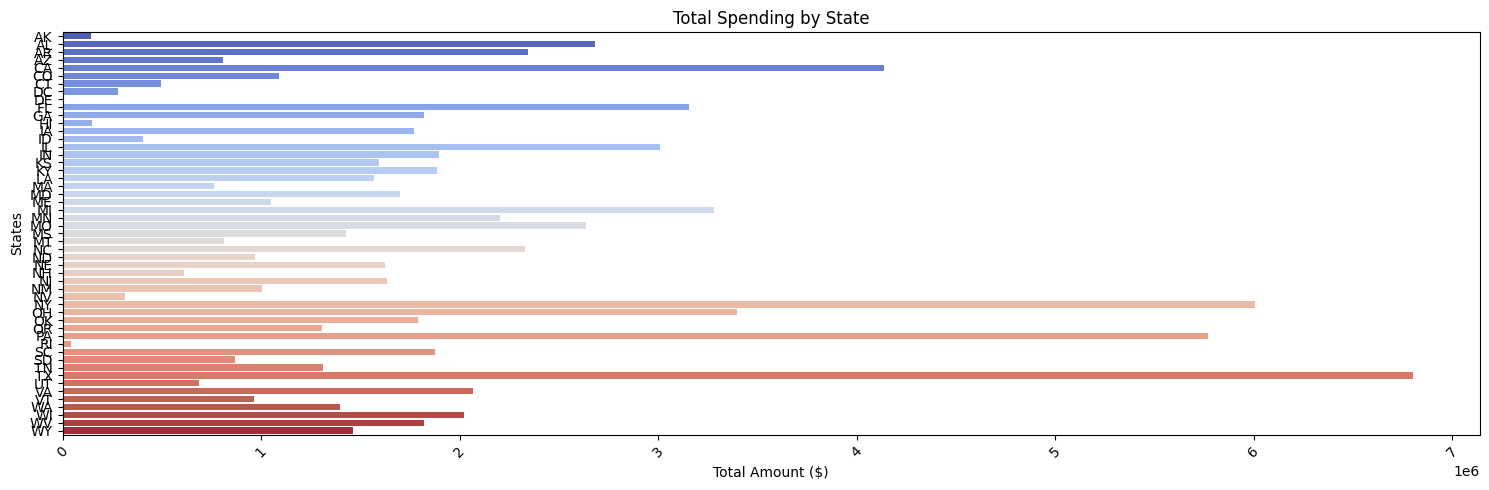

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

state_spending = df.groupby('state')['amt'].sum().reset_index()

plt.figure(figsize=(15,5))
sns.barplot(data=state_spending, y='state', x='amt', palette='coolwarm')
plt.title('Total Spending by State')
plt.xlabel('Total Amount ($)')
plt.ylabel('States')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("total_spending_by_state.png", dpi=300, bbox_inches='tight')
plt.show()


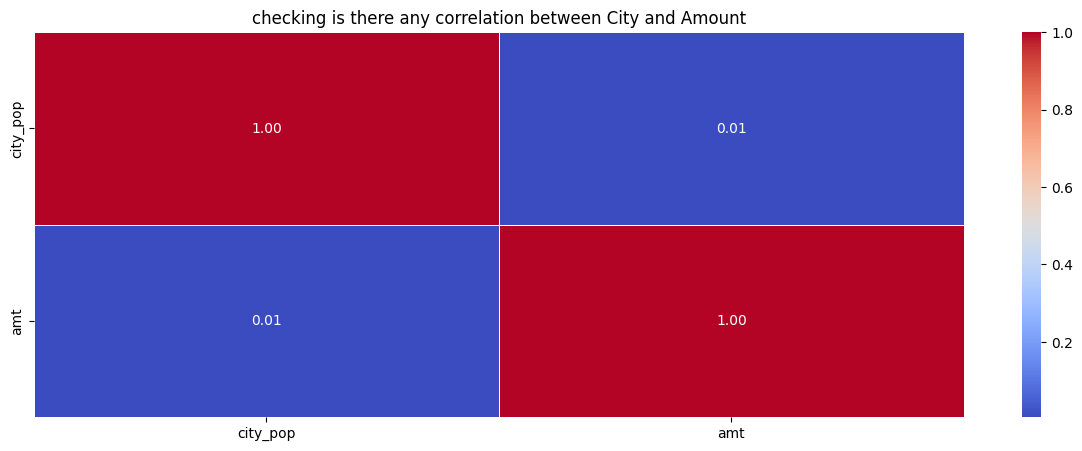

In [ ]:
correlation = df[['city_pop','amt']].corr()
plt.figure(figsize = (15,5))
sns.heatmap(correlation,cmap = 'coolwarm',fmt = '.2f',
            annot = True,linewidths= 0.5
            )
plt.title('checking is there any correlation between City and Amount')
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

📌 Insights on Spending Behavior and Location

1. City-Level Spending Trends


*   **Meridian,Houston,Brandon** have the highest total spending.

*   Spending is concentrated in a few key urban area,indicating higher economic activity.
2.State-Level Spending Trends


*   **Texas(TX),California(CA),and Florida(FL)** lead in total spending.

*   Warmer and more populous states tend to see higher consumer spending.

3.Correlation Between City Population and Spending


*   The correlation coefficient(0.0058) shows a very weak relationship between  city population and spending.

*   This suggests factors other then populations size, like income levels and industry presence, infulence spending behavior.

4.Key Takeaways


*   **Spending varies significantly by locations but is not soley dependent on population size.

*   Economic factors such as job markets, business activity, and regional wealth likely drive spending behavior.





#♦️ Part 5: Analyzing Spending Before and After Payday (Side-by-Side Plots)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 30 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat                    12966

In [ ]:
df['day_of_months'] = df['trans_date_trans_time'].dt.day
def categories_paydays(day):
  if day in [1,2,3,4,15,16,17,18,19]:
    return 'After Payday'
  else:
    return 'Before Payday'

df['payday_category'] = df['day_of_months'].apply(categories_paydays)
paydays_spending = df.groupby('payday_category')['amt'].agg(['mean','sum']).reset_index()
paydays_spending.columns = ['payday_category','Average_Transaction_amount','Total_Spending']
paydays_spending

,payday_category,Average_Transaction_amount,Total_Spending
0,After Payday,70.695442,27632303.2
1,Before Payday,70.202422,63590125.7


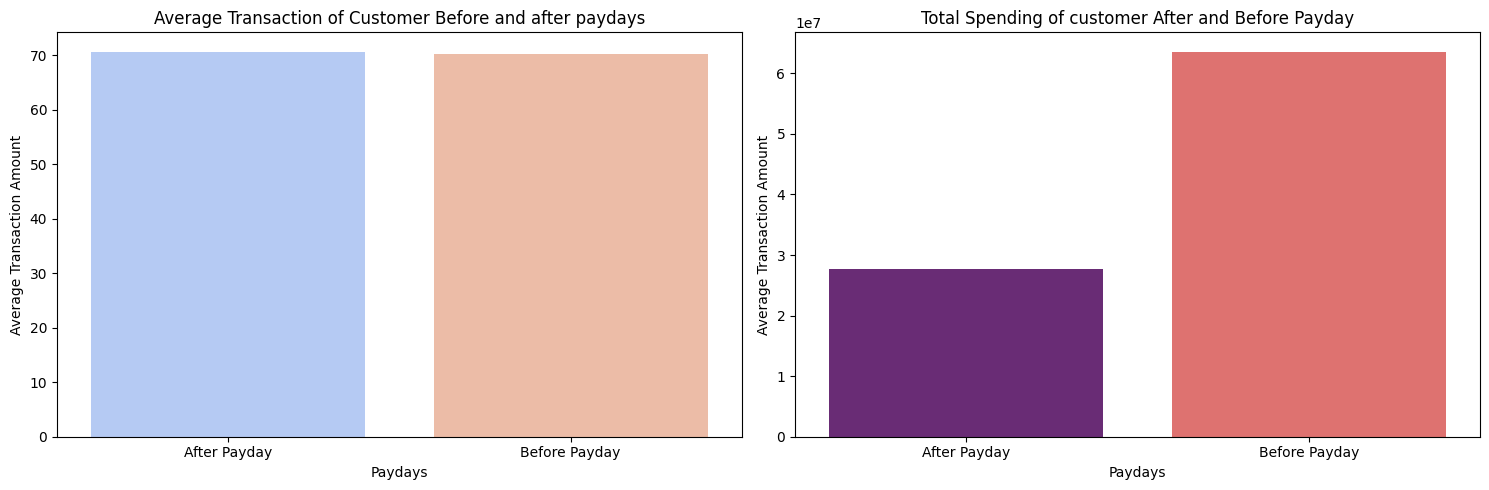

In [ ]:
fig, axes = plt.subplots(1,2,figsize = (15,5))
sns.barplot(ax = axes[0], x= paydays_spending['payday_category'],y = paydays_spending['Average_Transaction_amount'],palette='coolwarm' )
axes[0].set_title('Average Transaction of Customer Before and after paydays')
axes[0].set_xlabel('Paydays')
axes[0].set_ylabel('Average Transaction Amount')

sns.barplot(ax = axes[1],x = paydays_spending['payday_category'],y = paydays_spending['Total_Spending'],palette = 'magma')
axes[1].set_title('Total Spending of customer After and Before Payday')
axes[1].set_xlabel('Paydays')
axes[1].set_ylabel('Average Transaction Amount')


plt.tight_layout()
# Save heatmap
plt.savefig("AVg Transaction Amount and Total Spending BEfore and After Payday.png", dpi=300, bbox_inches='tight')
plt.show()
plt.show()


📌 Insights on Spending Behavior Before and After Payday


*   **Total spending is higer before payday** than after payday,indicating that people tend to spend more when they anticipate their next paycheck
*   **Average transaction amounts remain neraly the same** before and after payday,suggesting habits per transaction are consistent.


*   The surge in total spending before may reflect **bill payments, necessary expenses, or impulse purchases** before receiving the next paycheck.
*   After payday,spending may drop as individuals regain financial stability and budget for upcoming exenses.

#4.3 Advanced EDA Questions


---



---




1.Can we detect outliers in spending behavior using anomaly detection?

2.Are there clusters of customers based on spending habits? (Use K-Means, DBSCAN)

3.Can we use association rule mining (Apriori, FP-Growth) to find patterns in purchases?

4.How does spending behavior correlate with economic factors (e.g., inflation, interest rates)?


5.Can we use NLP on transaction descriptions to classify transactions more effectively?



♦️ Part 1: Detecting Outliers in Spending Behavior.


Number of outliers by the z_score: 12738
Number of outliers by the isolationforest: 129267


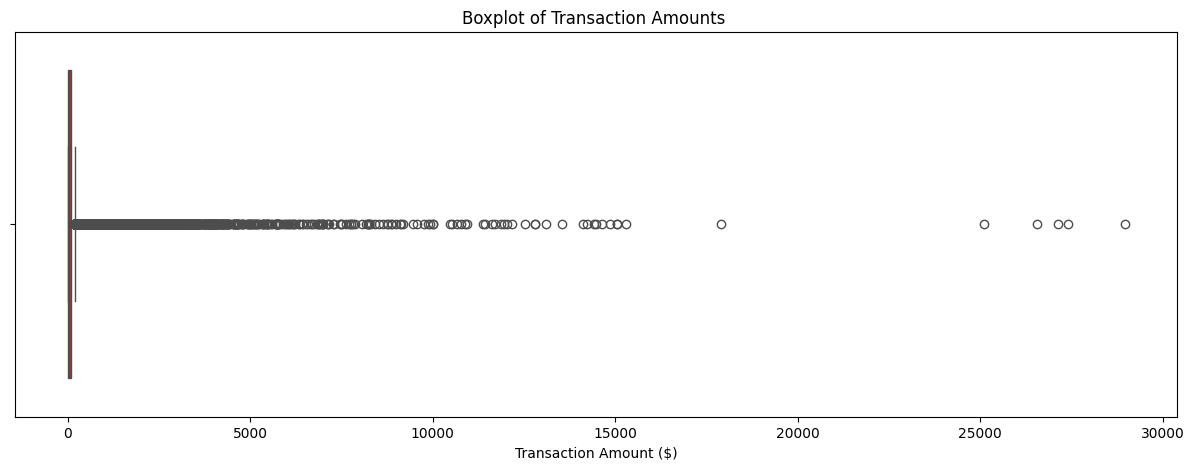

In [ ]:
df['z_score'] = np.abs(zscore(df['amt']))
df['outliers_z'] = df['z_score']>3
print(f'Number of outliers by the z_score: {df['outliers_z'].sum()}')

is_forest = IsolationForest(contamination=0.1,random_state = 42)
df['outliers_is'] = is_forest.fit_predict(df[['amt']])
df['outliers_is'] = df['outliers_is'] ==  -1

print(f'Number of outliers by the isolationforest: {df['outliers_is'].sum()}')

plt.figure(figsize = (15,5))
sns.boxplot(x = df['amt'],showfliers = True ,color = 'red')
plt.title('Boxplot of Transaction Amounts ')
plt.xlabel('Transaction Amount ($)')
plt.savefig('Boxplot of Transaction Amounts (Outliers in Red).png', dpi = 300,bbox_inches = 'tight')
plt.show()

#♦️ Part 2: Customer Clustering using K-Means & DBSCAN.




In [ ]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'customer_age', 'total_spent',
       'transaction_counts', 'transaction_date', 'transaction_month',
       'weekly_transaction', 'transaction_hours', 'spending_segment',
       'day_of_months', 'payday_category', 'z_score', 'outliers_z',
       'outliers_is'],
      dtype='object')

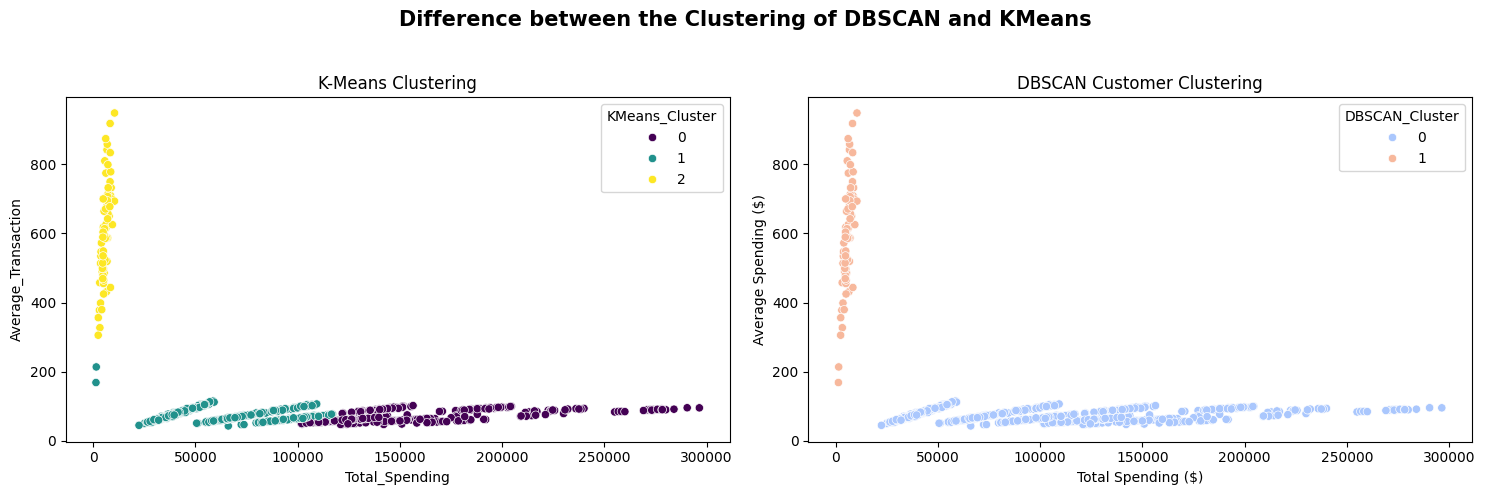

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

# Step 1: Aggregate spending per customer
customer_spending = df.groupby('cc_num')['amt'].agg(['mean', 'count', 'sum']).reset_index()
customer_spending.columns = ['Customer_ID', 'Average_Transaction', 'Number_of_Transaction', 'Total_Spending']

# Step 2: Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_spending[['Average_Transaction', 'Number_of_Transaction', 'Total_Spending']])

# Step 3: Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
customer_spending['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)

# Step 4: Apply DBSCAN
dbscan = DBSCAN(eps=1, min_samples=5)
customer_spending['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)

# Step 5: Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Difference between the Clustering of DBSCAN and KMeans', fontsize=15, fontweight='bold')

# K-Means plot
sns.scatterplot(
    ax=axes[0],
    x='Total_Spending',
    y='Average_Transaction',
    hue='KMeans_Cluster',
    palette='viridis',
    data=customer_spending,
    legend='full'
)
axes[0].set_title('K-Means Clustering')

# DBSCAN plot
sns.scatterplot(
    ax=axes[1],
    x='Total_Spending',
    y='Average_Transaction',
    hue='DBSCAN_Cluster',
    palette='coolwarm',
    data=customer_spending,
    legend='full'
)
axes[1].set_title('DBSCAN Customer Clustering')
axes[1].set_xlabel('Total Spending ($)')
axes[1].set_ylabel('Average Spending ($)')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout for the main title
plt.savefig('customer_clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
customer_spending.columns

Index(['Customer_ID', 'Average_Transaction', 'Number_of_Transaction',
       'Total_Spending', 'KMeans_Cluster', 'DBSCAN_Cluster'],
      dtype='object')

In [ ]:
from IPython.display import IFrame
import plotly.io as pio
import kaleido
px.scatter_3d(customer_spending,
                    x = 'Total_Spending',
                    y = 'Average_Transaction',
                    z = 'Number_of_Transaction',
                    hover_data= ['Customer_ID', 'Average_Transaction', 'Number_of_Transaction','Total_Spending'],
                    color = 'KMeans_Cluster',
                    title = '3D scatter plot of customer clusters')
#Not able to save the graph

📌 Insights Customer Clusters¶

1. **Three Customer Segments identified:**


*   **Frequent small spenders(Pink)**: High transaction count, low spending.

*   **Moderate spenders(Blue)**: Balanced spending and transaction frequency.


*   **High spenders(Yellow):** Low transaction count, very high spending.

Insights can help in **targeted marketing and customer segmentation**.


#5. Machine Learning Model - FaceBook Prophet


---



---

##Model Selection

We will use Facebook Prophet, a powerful time-series forecasting tool designed for financial and business data. It is robust to missing data and seasonal variations.

Steps to Build the model:

1.Prepare Data



*   Convert Transaction_date to time-series fromat.

*   Aggreagte transaction by day/month for each spending category.

1. Train Model

*   Use Transaction_Amount as the target variable.

*   Include external regressors(e.g.,holiday effects,economic factors).

1.Evaluate Model Performance



*  Use mertrics like MAE(mean Absolute Error) and RMSE(Root Mean Square Error).



*   Compare Prophet's forecast with actual data.

#🔹Step 1: Prepare Data

📌 Data Preprocessing Steps: Handling Skewness & Outliers**


In this updated approach, we focus on improving data distribution by handling outliers and skewness before applying time-series forecasting.



*   ✔ Capped outliers instead of removing them to retain valuable data.


*   ✔ Reduced skewness using log transformation for a more balanced distribution.

*   ✔ Enhanced data quality for better time-series forecasting and anomaly detection.


This refined preprocessing pipeline ensures better predictions and more accurate anomaly detection! 🚀


In [ ]:
from scipy.stats import skew

original_skew = skew(df['amt'])

print('Skewness of the data before any transforamtion:', original_skew)

Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)

IQR = Q3-Q1
LL = Q1 - 1.5*IQR
UL = Q3 + 1.5*IQR

df['amt'] = np.where(df['amt']<LL , LL , df['amt'])
df['amt'] = np.where(df['amt']>UL,UL,df['amt'])

clear_skewness = skew(df['amt'])
print(f'Skewness after the outliers handeling {clear_skewness}')

df['amt'] = np.log1p(df['amt'])
log_transform = skew(df['amt'])
print(f'Skewness after the log transformation {log_transform}')

Skewness of the data before any transforamtion: 42.2778248827837
Skewness after the outliers handeling 1.0619621755092699
Skewness after the log transformation -0.5351445480954713


In [ ]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,transaction_date,transaction_month,weekly_transaction,transaction_hours,spending_segment,day_of_months,payday_category,z_score,outliers_z,outliers_is
0,2019-01-01 00:00:18,2703186189652095,"Rippin, Kub and Mann",misc_net,1.786747,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,2019-01-01,1,1,0,High Spender,1,After Payday,0.407826,False,False
1,2019-01-01 00:00:44,630423337322,"Heller, Gutmann and Zieme",grocery_pos,4.684259,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,2019-01-01,1,1,0,High Spender,1,After Payday,0.230039,False,False
2,2019-01-01 00:00:51,38859492057661,Lind-Buckridge,entertainment,5.269789,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,2019-01-01,1,1,0,Low Spender,1,After Payday,0.934149,False,True
3,2019-01-01 00:01:16,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,3.828641,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,2019-01-01,1,1,0,Low Spender,1,After Payday,0.158132,False,False
4,2019-01-01 00:03:06,375534208663984,Keeling-Crist,misc_pos,3.760269,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,2019-01-01,1,1,0,High Spender,1,After Payday,0.177094,False,False


In [ ]:
df_prophet = df.groupby('transaction_date')['amt'].sum().reset_index()
df_prophet.columns = ['ds','y']
df_prophet.head()

,ds,y
0,2019-01-01,8331.115095
1,2019-01-02,3884.604087
2,2019-01-03,4359.996276
3,2019-01-04,5251.381450
4,2019-01-05,4968.719704


In [ ]:
df_prophet.tail()

,ds,y
532,2020-06-17,6408.971309
533,2020-06-18,7128.154739
534,2020-06-19,8634.369456
535,2020-06-20,8231.839923
536,2020-06-21,5159.706473


#🔹 Step 2: Train the Prophet Model


📌 Time-Series Forecasting with Facebook Prophet**



---

We employ Facebook Prophet, a robust time-series forecasting model, to predict future transaction amounts while incorporating multiple seasonal patterns.



*   **✔ Captures weekly, monthly, and yearly trends** for accurate long-term forecasting.
*   **✔ Provides confidence intervals** to assess uncertainty in predictions.



*   **✔ Enables proactive decision-making** for financial institutions and businesses.



With this approach, we ensure a **data-driven forecasting system** ready for real-world applications! 🚀

In [ ]:
model = Prophet(weekly_seasonality= True , yearly_seasonality= True)
model.add_seasonality(name = 'monthly', period = 30.5,fourier_order = 5)
model.fit(df_prophet)
forcast = model.make_future_dataframe(periods = 30, freq ='D')
future = model.predict(forcast)
future

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkr4c33_a/__9mo9ez.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkr4c33_a/s1x5okyx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67649', 'data', 'file=/tmp/tmpkr4c33_a/__9mo9ez.json', 'init=/tmp/tmpkr4c33_a/s1x5okyx.json', 'output', 'file=/tmp/tmpkr4c33_a/prophet_modelw30o7dal/prophet_model-20251024040539.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
04:05:39 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:05:39 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,monthly,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-01-01,8804.866643,6386.256243,10576.191834,8804.866643,8804.866643,-291.521868,-291.521868,-291.521868,140.777214,...,-1204.394734,-1204.394734,-1204.394734,772.095651,772.095651,772.095651,0.0,0.0,0.0,8513.344774
1,2019-01-02,8805.020218,4150.724359,8198.860624,8805.020218,8805.020218,-2595.285250,-2595.285250,-2595.285250,-314.279002,...,-2496.397441,-2496.397441,-2496.397441,215.391194,215.391194,215.391194,0.0,0.0,0.0,6209.734968
2,2019-01-03,8805.173793,4349.801243,8235.863993,8805.173793,8805.173793,-2590.334702,-2590.334702,-2590.334702,-544.588095,...,-1735.366012,-1735.366012,-1735.366012,-310.380595,-310.380595,-310.380595,0.0,0.0,0.0,6214.839091
3,2019-01-04,8805.327369,3807.204651,8079.803719,8805.327369,8805.327369,-2776.736585,-2776.736585,-2776.736585,-464.023704,...,-1512.175461,-1512.175461,-1512.175461,-800.537420,-800.537420,-800.537420,0.0,0.0,0.0,6028.590784
4,2019-01-05,8805.480944,6097.669531,10362.180651,8805.480944,8805.480944,-615.885133,-615.885133,-615.885133,-165.478980,...,800.800145,800.800145,800.800145,-1251.206299,-1251.206299,-1251.206299,0.0,0.0,0.0,8189.595811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,2020-07-17,8853.526112,6684.743381,10929.175514,8853.444526,8853.623654,-89.277267,-89.277267,-89.277267,218.319949,...,-1512.175461,-1512.175461,-1512.175461,1204.578245,1204.578245,1204.578245,0.0,0.0,0.0,8764.248846
563,2020-07-18,8853.570166,8761.702895,12878.677734,8853.484294,8853.674797,1924.527610,1924.527610,1924.527610,-74.377294,...,800.800145,800.800145,800.800145,1198.104759,1198.104759,1198.104759,0.0,0.0,0.0,10778.097776
564,2020-07-19,8853.614219,10507.341153,14662.944250,8853.524198,8853.726684,3720.583022,3720.583022,3720.583022,-372.716543,...,2908.200157,2908.200157,2908.200157,1185.099408,1185.099408,1185.099408,0.0,0.0,0.0,12574.197241
565,2020-07-20,8853.658273,10650.553650,14816.107812,8853.559050,8853.777525,3914.784837,3914.784837,3914.784837,-490.756843,...,3239.333347,3239.333347,3239.333347,1166.208334,1166.208334,1166.208334,0.0,0.0,0.0,12768.443110


In [ ]:
future[['ds','yhat','yhat_lower','yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2019-01-01,8513.344774,6386.256243,10576.191834
1,2019-01-02,6209.734968,4150.724359,8198.860624
2,2019-01-03,6214.839091,4349.801243,8235.863993
3,2019-01-04,6028.590784,3807.204651,8079.803719
4,2019-01-05,8189.595811,6097.669531,10362.180651


In [ ]:
with open('prophet_model.pkl', 'wb') as f:
    pickle.dump(model, f)

#🔹 Step 3: Visualize Forecast

Let's plot the forecast results.

📊 Visualizing the Transaction Forecast


---

**Forecast Plot**



*   The forecasted transaction amounts are plotted over time, providing a **clear visual representation** of expected trends.
*   Prophet's predictions include **confidence intervals**, highlighting potential variability in transaction amounts.


By visualizing the forecast, we enhance **data-driven insights** and ensure the model's predictions are effectively communicated. 🚀


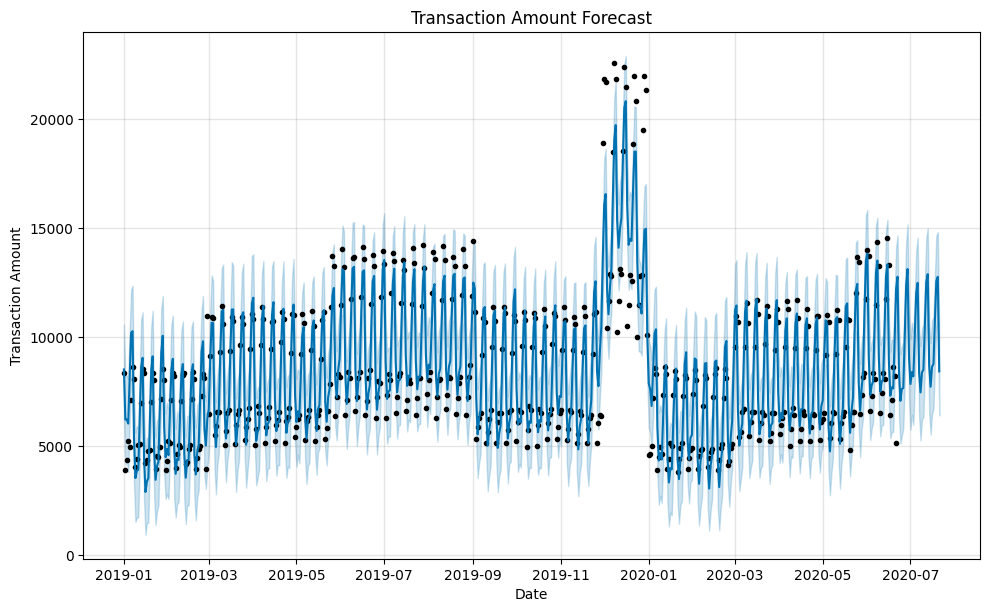

In [ ]:
fig = model.plot(future)
plt.title("Transaction Amount Forecast")
plt.xlabel("Date")
plt.ylabel("Transaction Amount")

# Save the figure
plt.savefig("transaction_forecast.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

# 🔹 Step 4: Visualizing Trend & Seasonality Components



---


Prophet allows us to break down the forecast into its components:



*   Trend (overall increase or decrease in spending)

*   Weekly Seasonality (how spending changes during the week)


*   Yearly Seasonality (if applicable, showing longer-term patterns)

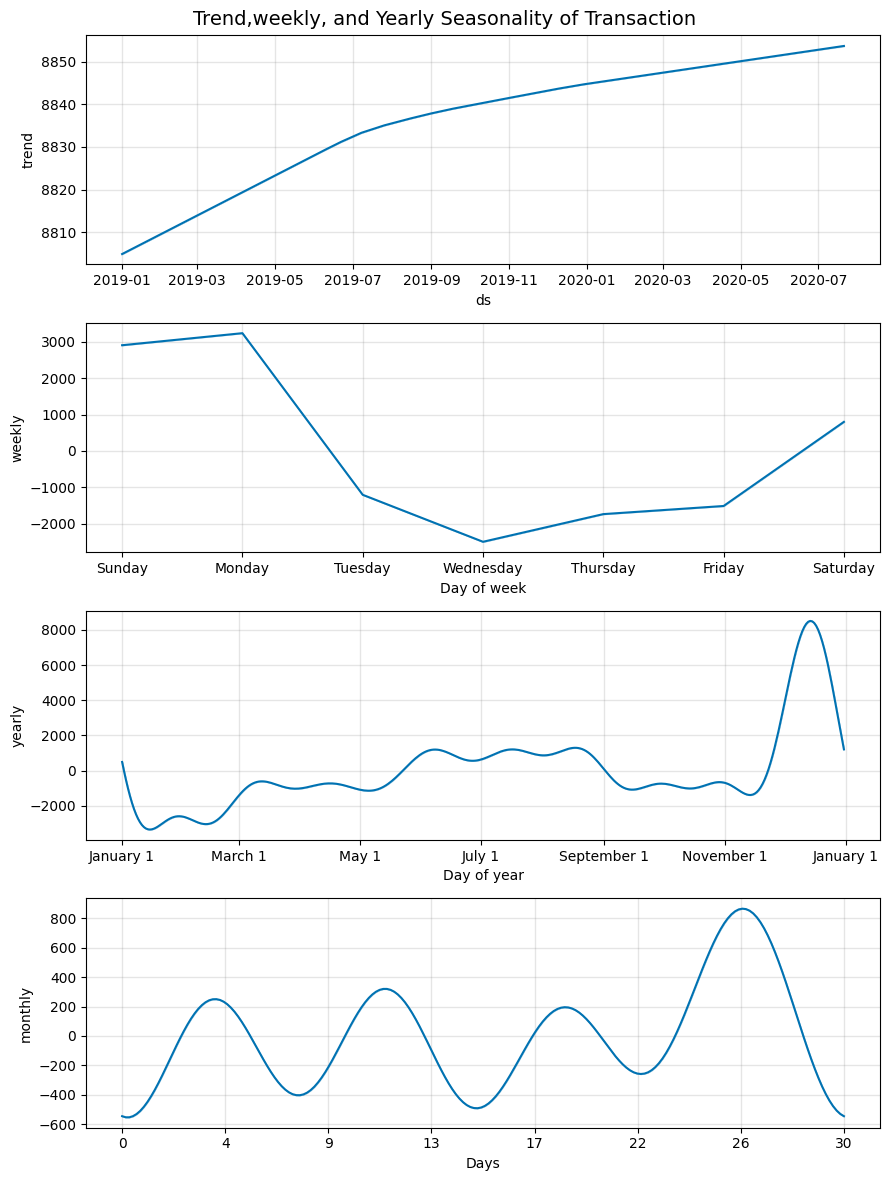

In [ ]:
fig_components = model.plot_components(future)
fig_components.suptitle('Trend,weekly, and Yearly Seasonality of Transaction',fontsize = 14)
# Save the figure
fig_components.savefig("transaction_components.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
# Show the plot
plt.show()

In [ ]:
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
future['ds'] = pd.to_datetime(future['ds'])

df_prophet = df_prophet.merge(future[['ds','yhat']],on = 'ds',how = 'left')

df_prophet["residual"] = df_prophet["y"] - df_prophet["yhat"]
threshold = 3 * np.std(df_prophet["residual"])
df_prophet["anomaly"] = np.abs(df_prophet["residual"]) > threshold
 # Mark anomalies

plt.figure(figsize=(12, 6))
plt.plot(df_prophet["ds"], df_prophet["y"], label="Actual", color="blue", alpha=0.6)
plt.plot(df_prophet["ds"], df_prophet["yhat"], label="Forecast", color="green", linestyle="dashed")
anomalies = df_prophet[df_prophet["anomaly"]]
plt.scatter(anomalies["ds"], anomalies["y"], color="red", label="Anomaly", marker="o", s=50)
plt.xlabel("Date")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount Forecast with Anomalies")
plt.legend()

# ✅ Save & Show the plot
plt.savefig("forecast_anomalies.png", dpi=300, bbox_inches="tight")
plt.show()

KeyError: "['yhat'] not in index"